In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [4]:
df=pd.read_csv('loan_approval.csv')
df

,cibil_score,collateral_value,monthly_income,loan_amount_requested,approved_loan_amount
0,652,251664,44736,1188848,1413123
1,820,541234,130859,88467,3000000
2,656,949684,130181,1086685,3000000
3,621,189182,149926,927844,2348810
4,738,522525,108084,530047,3000000
...,...,...,...,...,...
95,842,641460,95505,1328805,3000000
96,648,790976,20869,168834,2123126
97,721,831239,68108,1192424,3000000
98,763,143264,130296,1151497,2661811


In [5]:
df.shape

(100, 5)

In [6]:
df.columns

Index(['cibil_score', 'collateral_value', 'monthly_income',
       'loan_amount_requested', 'approved_loan_amount'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   cibil_score            100 non-null    int64
 1   collateral_value       100 non-null    int64
 2   monthly_income         100 non-null    int64
 3   loan_amount_requested  100 non-null    int64
 4   approved_loan_amount   100 non-null    int64
dtypes: int64(5)
memory usage: 4.0 KB


In [8]:
df.isnull().sum()

cibil_score              0
collateral_value         0
monthly_income           0
loan_amount_requested    0
approved_loan_amount     0
dtype: int64

In [9]:
df.corr()

,cibil_score,collateral_value,monthly_income,loan_amount_requested,approved_loan_amount
cibil_score,1.000000,-0.095719,0.214046,-0.097113,0.501932
collateral_value,-0.095719,1.000000,-0.040607,-0.089279,0.447223
monthly_income,0.214046,-0.040607,1.000000,0.082761,0.649896
loan_amount_requested,-0.097113,-0.089279,0.082761,1.000000,-0.013384
approved_loan_amount,0.501932,0.447223,0.649896,-0.013384,1.000000


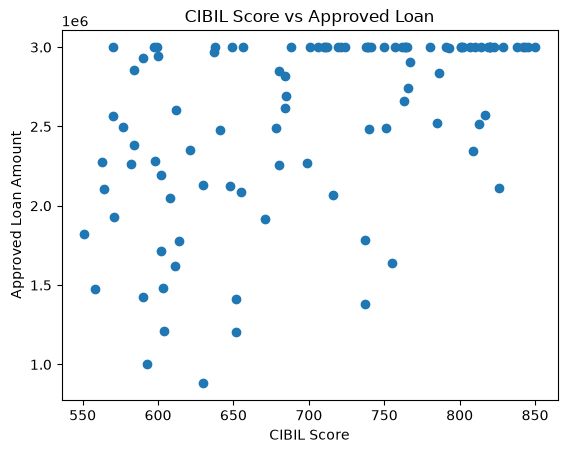

In [10]:

plt.scatter(df["cibil_score"], df["approved_loan_amount"])
plt.xlabel("CIBIL Score")
plt.ylabel("Approved Loan Amount")
plt.title("CIBIL Score vs Approved Loan")
plt.show()

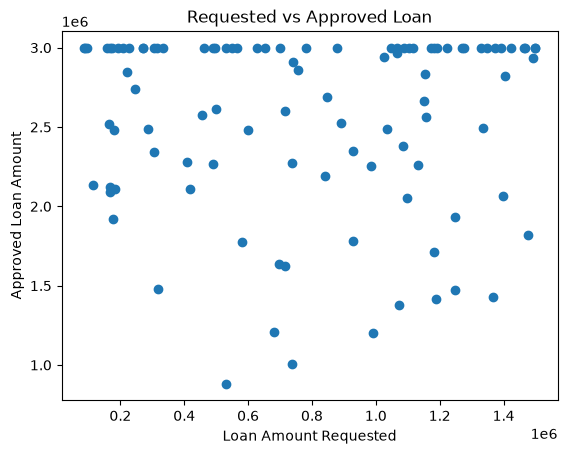

In [11]:
plt.scatter(df["loan_amount_requested"], df["approved_loan_amount"])
plt.xlabel("Loan Amount Requested")
plt.ylabel("Approved Loan Amount")
plt.title("Requested vs Approved Loan")
plt.show()

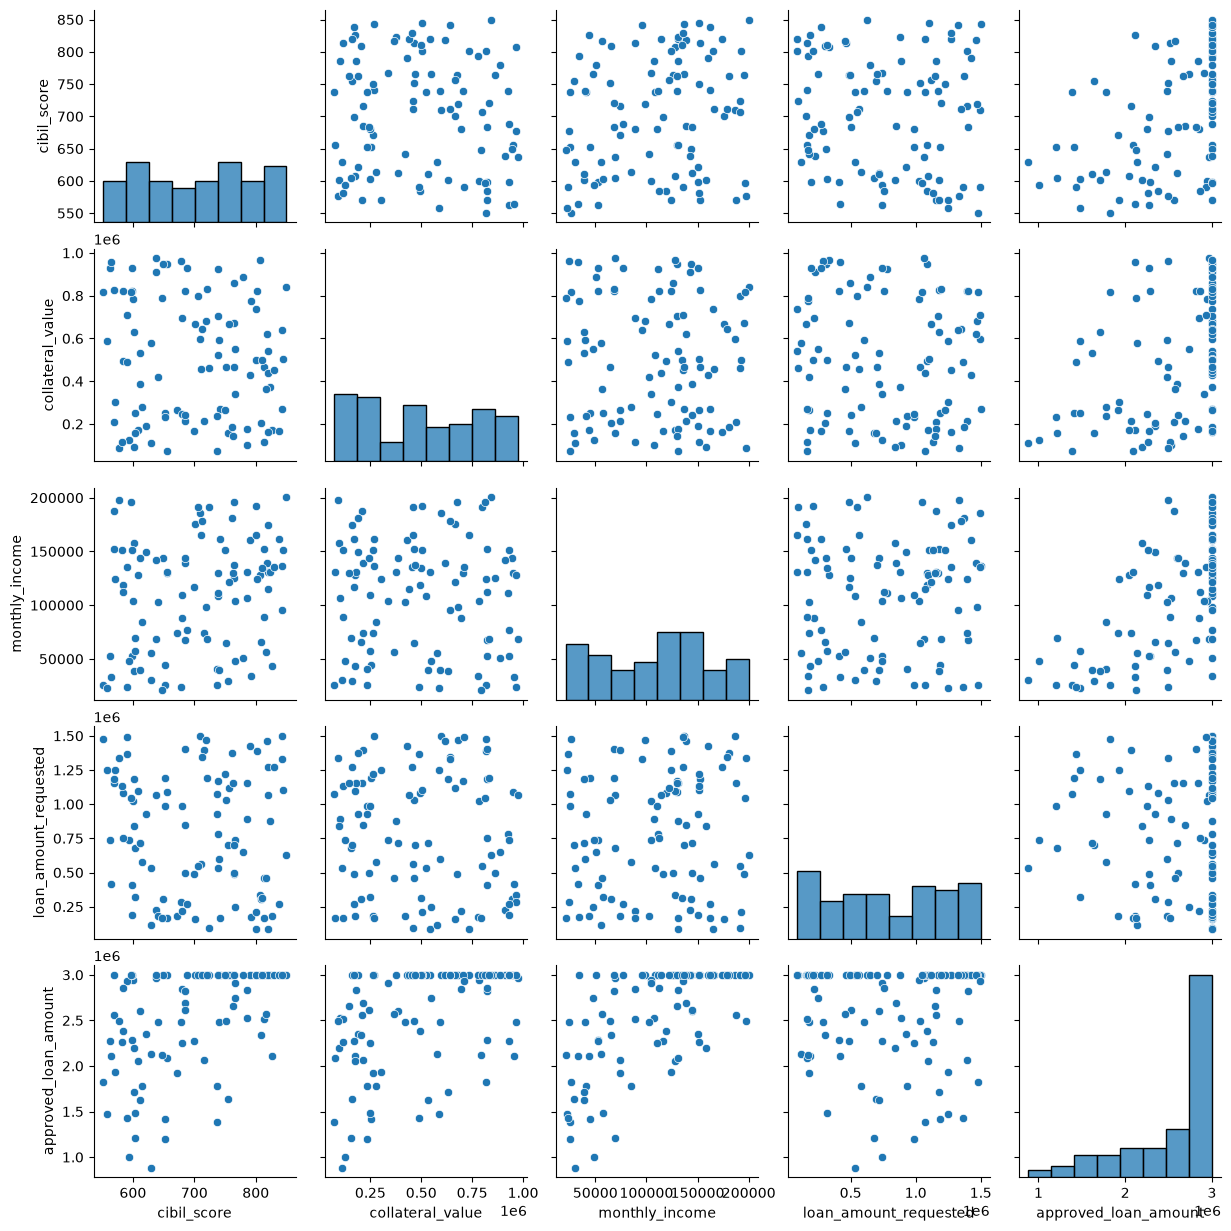

In [12]:
sns.pairplot(data=df)

<Axes: >

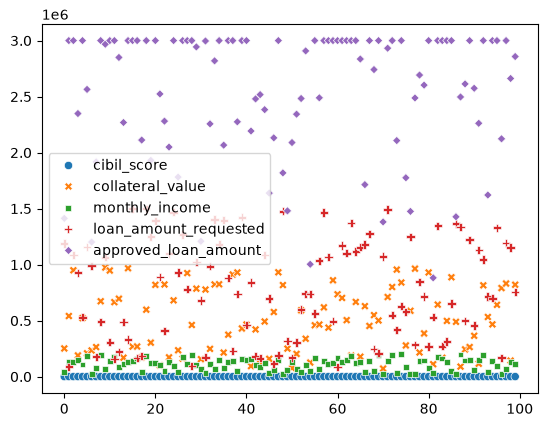

In [13]:
sns.scatterplot(data=df)

In [14]:
X=df.iloc[:,:4]
y=df.iloc[:,-1]

In [15]:
print(X.shape)
print(y.shape)

(100, 4)
(100,)


In [16]:
from sklearn.model_selection import train_test_split


In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 4)
(20, 4)
(80,)
(20,)


In [19]:
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[2547.29, 0.93, 6.28, 0.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['cibil_score','collateral_value','monthly_income','loan_amount_requested']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.766e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [21]:
y_pred=model.predict(X_test)
y_pred

array([2857874.11291869, 2516372.2726114 , 1732259.42761398,
       1845811.61788494, 2319288.29428925, 3084494.76858099,
       2180746.97316647, 2648501.9502217 , 2987316.62986857,
       1815070.189839  , 3202601.42205154, 1710683.2770721 ,
       2095151.40709455, 2592624.5429799 , 2341558.47795246,
       2618548.46171251, 1753533.86193067, 2324886.29651822,
       2478148.83435583, 2492821.31206488])

In [22]:
score =model.score(X_test,y_pred)
print("Model Trained Score",score)

Model Trained Score 1.0


In [23]:
df.sample()

,cibil_score,collateral_value,monthly_income,loan_amount_requested,approved_loan_amount
78,685,215838,138885,847079,2692332


In [33]:
cib=float(input("Enter cibil score"))
col=float(input("Enter collateral value"))
inc=float(input("Enter monthly income"))
req=float(input("Enter requested loan amount"))
user_data=[[cib,col,inc,req]]
prediction=model.predict(user_data)[0]
print("Model predicted price is",round(prediction,2))
print(f"Model giving maximum possible loan amount is {round(prediction,2)} with {score*100}% accuracy ")

Enter cibil score 300
Enter collateral value 0
Enter monthly income 40000
Enter requested loan amount 1000000


Model predicted price is 636823.75
Model giving maximum possible loan amount is 636823.75 with 100.0% accuracy 


/opt/homebrew/Cellar/jupyterlab/4.6.3/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [34]:
import numpy as np
errors = y_test.values - y_pred

mae = np.mean(np.abs(errors))

mse = np.mean(errors ** 2)

rmse = np.sqrt(mse)

print(f"Mean Absolute Error:  {mae:,.2f}")
print(f"Mean Square Error:  {mse:,.2f}")
print(f"Root Mean Square Error: {rmse:,.2f}")

Mean Absolute Error:  249,054.90
Mean Square Error:  84,314,123,742.24
Root Mean Square Error: 290,368.94


In [40]:
r2 = model.score(X_test, y_test)

print("R² Score:", r2)

R² Score: 0.8208805140096959
